In [4]:
import requests
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
from dotenv import load_dotenv

In [3]:
load_dotenv()

TNG_API_KEY = os.getenv("TNG_API_KEY")
headers = {"api-key": TNG_API_KEY}

# Base URL for TNG50-1
base_url = "https://www.tng-project.org/api/TNG50-1/"

**Download the Group Catalog (z=0, Snapshot 99)**

Only downloading halo and subhalo catalog

In [5]:
# URL for group catalog at snapshot 99 (z=0)
groupcat_url = base_url + "files/groupcat-99/"

# Request the file list
r = requests.get(groupcat_url, headers=headers)
files = r.json()
files.keys()

# Build full URLs correctly. Download all chunk files
file_names = files["files"]

for i, file_name in enumerate(file_names[:5]):  # starting with 5 files
    response = requests.get(file_name, headers=headers)

    if response.status_code != 200:
        print("FAILED:", file_name, response.status_code)
        continue

    filename = f"./tng/groupcat_99_{i}.hdf5"

    with open(filename, "wb") as f:
        f.write(response.content)

    print("Downloaded:", filename, "size:", len(response.content))

Downloaded: ./tng/groupcat_99_0.hdf5 size: 83404656
Downloaded: ./tng/groupcat_99_1.hdf5 size: 28160
Downloaded: ./tng/groupcat_99_2.hdf5 size: 28160
Downloaded: ./tng/groupcat_99_3.hdf5 size: 28160
Downloaded: ./tng/groupcat_99_4.hdf5 size: 28160


**Load the Data**

In [8]:
files_to_load = sorted(glob("./tng/groupcat_99_*.hdf5"))

for f in files_to_load:
    print(f, "size =", os.path.getsize(f))

# Open the group catalog file
# starting by loading the first file only
f = h5py.File(files_to_load[0], "r")

print("Loaded:", files_to_load[0])
print(f.keys())

./tng/groupcat_99_0.hdf5 size = 83404656
./tng/groupcat_99_1.hdf5 size = 28160
./tng/groupcat_99_2.hdf5 size = 28160
./tng/groupcat_99_3.hdf5 size = 28160
./tng/groupcat_99_4.hdf5 size = 28160
Loaded: ./tng/groupcat_99_0.hdf5
<KeysViewHDF5 ['Config', 'Group', 'Header', 'IDs', 'Parameters', 'Subhalo']>


**Extract Halo Information**

In [9]:
# Load halo (FoF group) data
Group_M200 = f["Group"]["Group_M_Crit200"][:]  # halo mass
Group_R200 = f["Group"]["Group_R_Crit200"][:]  # virial radius
GroupPos = f["Group"]["GroupPos"][:]  # halo positions

# Convert to physical Msun (multiply by 1e10 / h)
h = 0.6774
Group_M200 = Group_M200 * 1e10 / h

print("Number of halos:", len(Group_M200))

print("Min mass:", np.min(Group_M200))
print("Max mass:", np.max(Group_M200))

Number of halos: 1
Min mass: 183494020000000.0
Max mass: 183494020000000.0


**Select Milky Way-Like Halos**

In [10]:
# Select MW-like halos (mass ~10^12 Msun)
mw_mask = (Group_M200 > 5e11) & (Group_M200 < 2e12)

mw_indices = np.where(mw_mask)[0]

print("Number of MW-like halos:", len(mw_indices))

Number of MW-like halos: 0


**Load Subhalo Data**

In [11]:
SubhaloMassType = f["Subhalo"]["SubhaloMassType"][:]
SubhaloPos = f["Subhalo"]["SubhaloPos"][:]
SubhaloGrNr = f["Subhalo"]["SubhaloGrNr"][:]

# Convert masses to Msun
SubhaloMassType = SubhaloMassType * 1e10 / h

# Dark matter mass = column 1
dm_mass = SubhaloMassType[:, 1]

# Stellar mass = column 4
stellar_mass = SubhaloMassType[:, 4]

print("Number of subhalos:", len(dm_mass))

Number of subhalos: 63864


**Select Subhalo Around Milky Way-Like Hosts**

In [12]:
# Find subhalos belonging to MW halos
mw_subhalo_mask = np.isin(SubhaloGrNr, mw_indices)

mw_dm_mass = dm_mass[mw_subhalo_mask]
mw_stellar_mass = stellar_mass[mw_subhalo_mask]
mw_positions = SubhaloPos[mw_subhalo_mask]
mw_hosts = SubhaloGrNr[mw_subhalo_mask]

print("Subhalos in MW-like systems:", len(mw_dm_mass))

Subhalos in MW-like systems: 0


**Compute Radial Distances**

In [13]:
radii = []

for i in range(len(mw_positions)):
    host_index = mw_hosts[i]
    host_pos = GroupPos[host_index]

    r = np.linalg.norm(mw_positions[i] - host_pos)
    radii.append(r)

radii = np.array(radii)

print("Computed radial distances.")

Computed radial distances.


**Subhalo Mass Function Plot**

/var/folders/6_/_ttpd4h161x6qj1yw7d3rsyr0000gn/T/ipykernel_19555/904106458.py:4: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


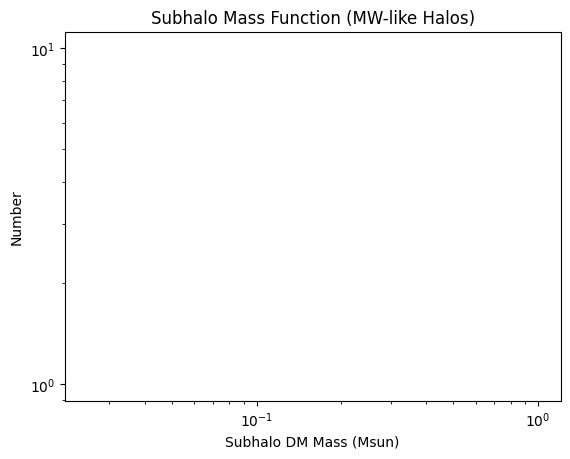

In [14]:
plt.figure()
plt.hist(mw_dm_mass, bins=40)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Subhalo DM Mass (Msun)")
plt.ylabel("Number")
plt.title("Subhalo Mass Function (MW-like Halos)")
plt.show()

**Estimate Stream-Perturbing Subhalos**

In [15]:
perturber_mask = (mw_dm_mass > 1e6) & (mw_dm_mass < 1e9) & (radii < 50)

print("Number of potential stream-perturbing subhalos:")
print(np.sum(perturber_mask))

Number of potential stream-perturbing subhalos:
0
